# 3.1 — Rétropropagation from scratch : la chaîne des gradients à la main

**Navigation** : [<< 2.9-Grokking-Generalisation](../02-ML-Cours/2.9-Grokking-Generalisation.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook 2.2 a fait descendre un coût le long de sa dérivée : c'est la descente de gradient. Un réseau de neurones fait exactement la même chose — sauf que ses paramètres se comptent ici en dizaines, en millions en pratique, et que la dérivée du coût par rapport à *chacun* d'eux exige de remonter le réseau couche par couche. Cette remontée, c'est la **rétropropagation** : la règle de dérivation en chaîne (*chain rule*) appliquée méthodiquement de la sortie vers l'entrée. C'est elle que PyTorch exécute en silence à chaque appel de `loss.backward()`.

Pourquoi l'écrire à la main, alors qu'autograd existe ? Parce que « le réseau apprend » reste une boîte noire tant qu'on n'a pas écrit, une fois, le gradient à la main — et surtout vérifié qu'il est **juste** par différence finie. Après ce notebook, `backward()` ne sera plus une formule magique : ce sera une ligne de code que vous avez écrite vous-mêmes, et qu'on comparera trait pour trait à PyTorch.

Ce notebook ouvre la sous-série **03-DeepLearning**, en prolongement direct de 02-ML-Cours : même style (tout from scratch d'abord, la bibliothèque ensuite), un jeu de données jouet, une seule nouvelle idée — le gradient qui se propage.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Dériver et implémenter la passe avant **et** la passe arrière d'un MLP 2 → 8 → 1 en **NumPy pur** (aucun PyTorch pour apprendre).
2. **Vérifier un gradient calculé à la main par différence finie** — écart attendu < 1e-7 : la preuve numérique que la dérivation est juste.
3. Entraîner le réseau sur `make_moons` et visualiser la frontière de décision qui se courbe au fil des itérations.
4. Montrer que PyTorch (`nn.Linear` + autograd + `SGD`) reproduit **la même trajectoire et les mêmes poids** que notre implémentation.
5. Diagnostiquer le départ raté de l'initialisation à zéros (symétrie, col, échappée tardive) face à l'initialisation de Xavier.

### Prérequis

- Notebook 2.2 (descente de gradient, dérivée, learning rate).
- Notebook 2.3 (régression logistique, sigmoïde, entropie croisée).
- Notebook 2.5b (la BCE est la même perte que la log-vraisemblance de la régression logistique).

> **Référence.** Rumelhart, Hinton & Williams (1986), *Learning representations by back-propagating errors*, Nature 323 — l'article qui a popularisé la rétropropagation.


In [1]:
import warnings

def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _warn_no_path
# Configuration et imports pour le notebook 3.1
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

# Deux demi-lunes imbriquees : le jouet classique de la classification non lineaire
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Configuration OK : 3.1 - Retropropagation from scratch")
print(f"Entrainement : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Dimensions de X : {X.shape} (2 variables), classes presentes : {np.unique(y).tolist()}")
print(f"Classes equilibrees dans le train : {np.bincount(y_train).tolist()}")
print(f"torch {torch.__version__} | CUDA disponible : {torch.cuda.is_available()} (inutilise ici, voir section 5)")


Configuration OK : 3.1 - Retropropagation from scratch
Entrainement : 210 lignes | Test : 90 lignes
Dimensions de X : (300, 2) (2 variables), classes presentes : [0, 1]
Classes equilibrees dans le train : [105, 105]


torch 2.6.0+cu124 | CUDA disponible : True (inutilise ici, voir section 5)


## 1. Le problème : deux lunes qu'aucune droite ne peut séparer

Le jeu de données `make_moons` dessine deux arcs imbriqués — deux « lunes » face à face. C'est le contre-exemple canonique du modèle linéaire : la régression logistique du notebook 2.3 trace une **droite** comme frontière de décision, et aucune droite ne peut isoler une lune qui enserre l'autre. Le meilleur séparateur linéaire laisse forcément des points des deux classes de chaque côté.

La figure ci-dessous confronte les données (panneau de gauche) à la meilleure frontière linéaire, apprise par `LogisticRegression` (panneau de droite) : la droite coupe les lunes en travers et l'accuracy plafonne. Pour faire mieux, il faut un modèle capable de **courber** sa frontière : un perceptron multicouche (MLP) avec une couche cachée.


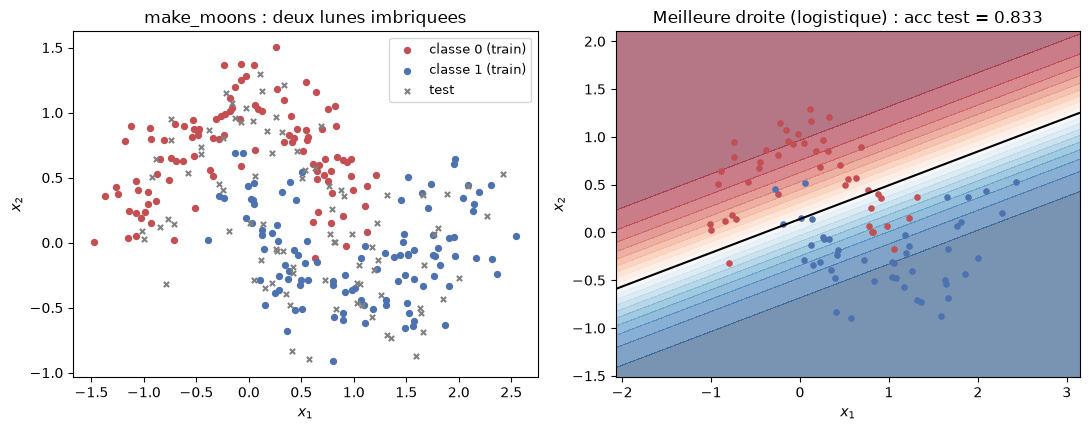

Frontiere lineaire : acc train = 0.867 | acc test = 0.833
Aucune droite ne fait mieux sur ces donnees -> il faut courber la frontiere, donc une couche cachee.


In [2]:
# Figure 1 : les donnees, puis la meilleure frontiere LINEAIRE (regression logistique de 2.3)
logreg = LogisticRegression().fit(X_train, y_train)
acc_lin_train = logreg.score(X_train, y_train)
acc_lin_test = logreg.score(X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="#c44e52", s=18, label="classe 0 (train)")
axes[0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="#4c72b0", s=18, label="classe 1 (train)")
axes[0].scatter(X_test[:, 0], X_test[:, 1], color="gray", s=14, marker="x", label="test")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].set_title("make_moons : deux lunes imbriquees")
axes[0].legend(loc="upper right", fontsize=9)

x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
proba_lin = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)
axes[1].contourf(xx, yy, proba_lin, levels=np.linspace(0, 1, 21), cmap="RdBu", alpha=0.55)
axes[1].contour(xx, yy, proba_lin, levels=[0.5], colors="k", linewidths=1.5)
axes[1].scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color="#c44e52", s=14)
axes[1].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color="#4c72b0", s=14)
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
axes[1].set_title(f"Meilleure droite (logistique) : acc test = {acc_lin_test:.3f}")

fig.tight_layout()
plt.show()

print(f"Frontiere lineaire : acc train = {acc_lin_train:.3f} | acc test = {acc_lin_test:.3f}")
print("Aucune droite ne fait mieux sur ces donnees -> il faut courber la frontiere, donc une couche cachee.")


### L'architecture 2 → 8 → 1 et la passe avant

Un MLP minimal à une couche cachée, en notations matricielles (N exemples en ligne) :

- $Z_1 = X W_1 + b_1$ de taille $(N, 8)$, puis $A_1 = \sigma(Z_1)$ : **8 neurones cachés**, chacun une sigmoïde d'une combinaison linéaire des 2 entrées ;
- $Z_2 = A_1 W_2 + b_2$ de taille $(N, 1)$, puis $\hat{y} = \sigma(Z_2)$ : **une probabilité de sortie**.

Soit quatre tenseurs de paramètres — $W_1$ $(2 \times 8)$, $b_1$ $(8)$, $W_2$ $(8 \times 1)$, $b_2$ $(1)$ — **33 paramètres** au total. Chaque neurone caché apprend son propre « détecteur » (une petite frontière orientée dans le plan), et la sortie agrège les 8 détecteurs en une probabilité. La **passe avant** n'est que ces deux produits matriciels : le réseau non entraîné sait déjà l'exécuter — il prédit simplement n'importe quoi.

L'initialisation : chaque poids est tiré selon $\mathcal{N}(0, 1/\mathrm{fan\_in})$ (Xavier, calibrée pour la sigmoïde — la section 6 montre pourquoi le choix importe), les biais à zéro.


In [3]:
# Le MLP 2 -> 8 -> 1 en NumPy pur : initialisation Xavier + passe avant
H = 8  # largeur de la couche cachee

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def init_params(seed=42, mode="xavier"):
    """Initialise (W1, b1, W2, b2).

    mode="xavier" : poids ~ N(0, 1/fan_in), variance calibree pour la sigmoide
    (Glorot & Bengio, 2010). mode="zeros" : tout a zero (section 6).
    """
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    if mode == "xavier":
        W1 = rng.normal(0.0, np.sqrt(1.0 / d), size=(d, H))
        W2 = rng.normal(0.0, np.sqrt(1.0 / H), size=(H, 1))
    else:  # zeros
        W1 = np.zeros((d, H))
        W2 = np.zeros((H, 1))
    b1 = np.zeros(H)
    b2 = np.zeros(1)
    return W1, b1, W2, b2

def forward(params, Xd):
    """Passe avant : retourne (y_hat, cache). Le cache sert a la passe arriere."""
    W1, b1, W2, b2 = params
    z1 = Xd @ W1 + b1     # (N, 8)
    a1 = sigmoid(z1)      # (N, 8)
    z2 = a1 @ W2 + b2     # (N, 1)
    y_hat = sigmoid(z2)   # (N, 1)
    return y_hat, (z1, a1, z2)

def bce_loss(y_hat, y):
    """Entropie croisee binaire moyenne (la meme perte que la regression logistique 2.3)."""
    y_hat = np.clip(y_hat, 1e-12, 1.0 - 1e-12)
    y = y.reshape(-1, 1)
    return float(np.mean(-(y * np.log(y_hat) + (1.0 - y) * np.log(1.0 - y_hat))))

params = init_params(seed=42, mode="xavier")
y_hat_test, _ = forward(params, X_test)
acc_init = ((y_hat_test > 0.5).astype(int).ravel() == y_test).mean()

print(f"Parametres : W1 {params[0].shape}, b1 {params[1].shape}, W2 {params[2].shape}, b2 {params[3].shape}"
      f" -> {sum(p.size for p in params)} au total")
print(f"Reseau non entraine : loss BCE (test) = {bce_loss(y_hat_test, y_test):.4f}")
print(f"Accuracy test d'un reseau non entraine : {acc_init:.3f} -- autant tirer a pile ou face")


Parametres : W1 (2, 8), b1 (8,), W2 (8, 1), b2 (1,) -> 33 au total
Reseau non entraine : loss BCE (test) = 0.6781
Accuracy test d'un reseau non entraine : 0.589 -- autant tirer a pile ou face


## 2. La passe arrière à la main : la chain rule couche par couche

Apprendre = ajuster les 33 paramètres dans le sens opposé du gradient de la loss. La loss est la BCE (entropie croisée binaire moyenne — celle de la régression logistique du notebook 2.3). Il faut donc $\partial L / \partial W_1$, $\partial L / \partial b_1$, $\partial L / \partial W_2$, $\partial L / \partial b_2$. La chain rule les construit en remontant, en quatre étapes.

**Étape 1 — la sortie : BCE et sigmoïde se compensent.** Côté loss, $\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$ ; côté activation, $\sigma'(z_2) = \hat{y}(1 - \hat{y})$. Le produit des deux se simplifie en

$$\delta_2 \equiv \frac{\partial L}{\partial z_2} = \hat{y} - y$$

— littéralement *l'erreur de prédiction*. Cette simplification est la raison pour laquelle on couple toujours BCE et sigmoïde : sans elle, le facteur $\sigma'$ s'écraserait vers 0 quand $\hat{y}$ approche 0 ou 1, et le gradient s'éteindrait.

**Étape 2 — gradients de la dernière couche** (règle de dimensions : le gradient d'un paramètre a la forme du paramètre) :

$$\frac{\partial L}{\partial W_2} = A_1^\top \delta_2, \qquad \frac{\partial L}{\partial b_2} = \sum_n \delta_2^{(n)}$$

avec le facteur $1/N$ de la moyenne rangé dans $\delta_2$ dans le code ci-dessous.

**Étape 3 — remonter à travers $W_2$ vers la couche cachée :**

$$\frac{\partial L}{\partial A_1} = \delta_2 W_2^\top, \qquad \delta_1 \equiv \frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \odot A_1 (1 - A_1)$$

où $\odot$ est le produit terme à terme et $A_1 \odot (1 - A_1)$ est $\sigma'(Z_1)$ réécrit sans $Z_1$ — c'est à ça que sert le *cache* de la passe avant.

**Étape 4 — gradients de la première couche :**

$$\frac{\partial L}{\partial W_1} = X^\top \delta_1, \qquad \frac{\partial L}{\partial b_1} = \sum_n \delta_1^{(n)}$$

Le motif « $\delta$ → gradients → nouveau $\delta$ » est **le même à chaque couche** : empiler des couches ne fait qu'empiler des étapes 2–3. C'est toute la rétropropagation.


In [4]:
# Passe arriere en NumPy pur : la chain rule, couche par couche
def backward(params, Xd, y, cache):
    """Retourne (dW1, db1, dW2, db2) : gradient de la BCE moyenne pour chaque parametre."""
    W1, b1, W2, b2 = params
    z1, a1, z2 = cache
    N = Xd.shape[0]
    y_col = y.reshape(-1, 1)

    dz2 = (sigmoid(z2) - y_col) / N   # (N,1)  etape 1 : BCE + sigmoide -> y_hat - y (facteur 1/N range ici)
    dW2 = a1.T @ dz2                  # (8,1)  etape 2
    db2 = dz2.sum(axis=0)             # (1,)
    da1 = dz2 @ W2.T                  # (N,8)  etape 3 : remonter a travers W2
    dz1 = da1 * a1 * (1.0 - a1)       # (N,8)  etape 3 : x sigmoide'(z1) = a1 (1 - a1)
    dW1 = Xd.T @ dz1                  # (2,8)  etape 4
    db1 = dz1.sum(axis=0)             # (8,)
    return dW1, db1, dW2, db2

y_hat_train, cache = forward(params, X_train)
grads = backward(params, X_train, y_train, cache)

print("Formes des gradients (doivent egaler celles des parametres) :")
for name, p, g in zip(["W1", "b1", "W2", "b2"], params, grads):
    print(f"  d{name} {str(g.shape):8s} (parametre {str(p.shape):8s}) | |grad| moyen = {np.abs(g).mean():.2e}")


Formes des gradients (doivent egaler celles des parametres) :
  dW1 (2, 8)   (parametre (2, 8)  ) | |grad| moyen = 9.06e-03
  db1 (8,)     (parametre (8,)    ) | |grad| moyen = 2.43e-03
  dW2 (8, 1)   (parametre (8, 1)  ) | |grad| moyen = 3.85e-02
  db2 (1,)     (parametre (1,)    ) | |grad| moyen = 4.72e-02


In [5]:
# VERIFICATION du gradient par difference finie : la preuve numerique que la derivation est juste
def flatten(pl):
    return np.concatenate([p.ravel() for p in pl])

def unflatten(theta):
    """Reconstruit (W1, b1, W2, b2) depuis le vecteur plat theta."""
    formes = [(X.shape[1], H), (H,), (H, 1), (1,)]
    out, i = [], 0
    for f in formes:
        n = int(np.prod(f))
        out.append(theta[i:i + n].reshape(f))
        i += n
    return tuple(out)

def loss_at(theta, Xd, y):
    y_hat, _ = forward(unflatten(theta), Xd)
    return bce_loss(y_hat, y)

theta = flatten(params)
grad_flat = flatten(grads)
eps = 1e-5
idx_choisis = [3, 12, 19, 27, 32]  # pioches dans W1, W1, b1, W2 et b2

print(f"{'indice':>7} {'grad analytique':>17} {'grad numerique':>17} {'ecart':>10}")
ecarts = []
for i in idx_choisis:
    tp, tm = theta.copy(), theta.copy()
    tp[i] += eps
    tm[i] -= eps
    g_num = (loss_at(tp, X_train, y_train) - loss_at(tm, X_train, y_train)) / (2 * eps)
    ecart = abs(grad_flat[i] - g_num)
    ecarts.append(ecart)
    print(f"{i:>7} {grad_flat[i]:>17.3e} {g_num:>17.3e} {ecart:>10.1e}")

max_ecart = max(ecarts)
verdict = "VERIFIE : la derivation manuelle est juste" if max_ecart < 1e-7 else "PROBLEME : revoir la derivation"
print(f"\nEcart max analytique vs numerique : {max_ecart:.2e} (seuil 1e-7) -> {verdict}")


 indice   grad analytique    grad numerique      ecart
      3         7.921e-04         7.921e-04    3.1e-12
     12        -2.714e-03        -2.714e-03    1.0e-11
     19        -2.178e-04        -2.178e-04    1.3e-11
     27         1.649e-02         1.649e-02    3.0e-12
     32         4.718e-02         4.718e-02    8.0e-13

Ecart max analytique vs numerique : 1.33e-11 (seuil 1e-7) -> VERIFIE : la derivation manuelle est juste


## 3. La boucle d'entraînement : suivre le gradient, 20 000 fois

Il ne reste qu'à assembler : à chaque itération, passe avant (on garde le cache), passe arrière (les 4 gradients), puis un pas de descente $\theta \leftarrow \theta - \eta \nabla_\theta L$ pour chacun des 33 paramètres. Learning rate $\eta = 0.5$, 20 000 itérations (quelques secondes de CPU — le full-batch NumPy sur 210 exemples est très rapide), **full-batch** : tout le train sert à chaque pas, comme au notebook 2.2 — pas de mini-batchs, le mécanisme à nu.

Deux lectures à préparer. La loss BCE vaut $\ln 2 \approx 0{,}693$ pour des prédictions au hasard ; nettement en dessous de 0.10, le réseau est confiant et rarement faux. Et la frontière de décision raconte la même histoire en image : nous prenons des instantanés aux itérations 0, 1 000, 5 000 et 20 000.


Loss BCE (train) : 0.6699 -> 0.0529 en 20000 iterations
Accuracy test du reseau entraine : 0.944


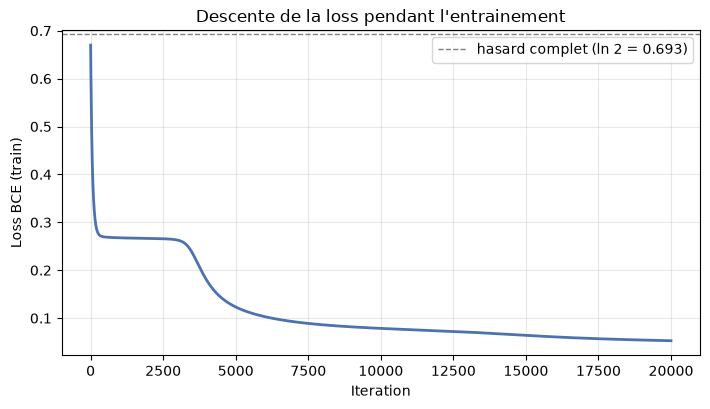

In [6]:
# Boucle d'entrainement full-batch : descente de gradient toute simple
def train_mlp(params, Xd, y, lr=0.5, iters=5000, snapshots_at=()):
    """Descente full-batch. Retourne (params_finaux, loss_history, {iteration: params})."""
    loss_history = np.empty(iters)
    snaps = {0: tuple(p.copy() for p in params)}
    for it in range(iters):
        y_hat, cache = forward(params, Xd)
        loss_history[it] = bce_loss(y_hat, y)
        dW1, db1, dW2, db2 = backward(params, Xd, y, cache)
        params = (params[0] - lr * dW1, params[1] - lr * db1,
                  params[2] - lr * dW2, params[3] - lr * db2)
        if (it + 1) in snapshots_at:
            snaps[it + 1] = tuple(p.copy() for p in params)
    return params, loss_history, snaps

params_train, loss_hist, snaps = train_mlp(
    init_params(seed=42, mode="xavier"), X_train, y_train,
    lr=0.5, iters=20000, snapshots_at=(1000, 5000, 20000),
)

y_hat_test, _ = forward(params_train, X_test)
acc_test = ((y_hat_test > 0.5).astype(int).ravel() == y_test).mean()

print(f"Loss BCE (train) : {loss_hist[0]:.4f} -> {loss_hist[-1]:.4f} en 20000 iterations")
print(f"Accuracy test du reseau entraine : {acc_test:.3f}")

plt.figure(figsize=(7.2, 4.2))
plt.plot(loss_hist, color="#4c72b0", linewidth=2)
plt.axhline(np.log(2), color="gray", linestyle="--", linewidth=1, label="hasard complet (ln 2 = 0.693)")
plt.xlabel("Iteration"); plt.ylabel("Loss BCE (train)")
plt.title("Descente de la loss pendant l'entrainement")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


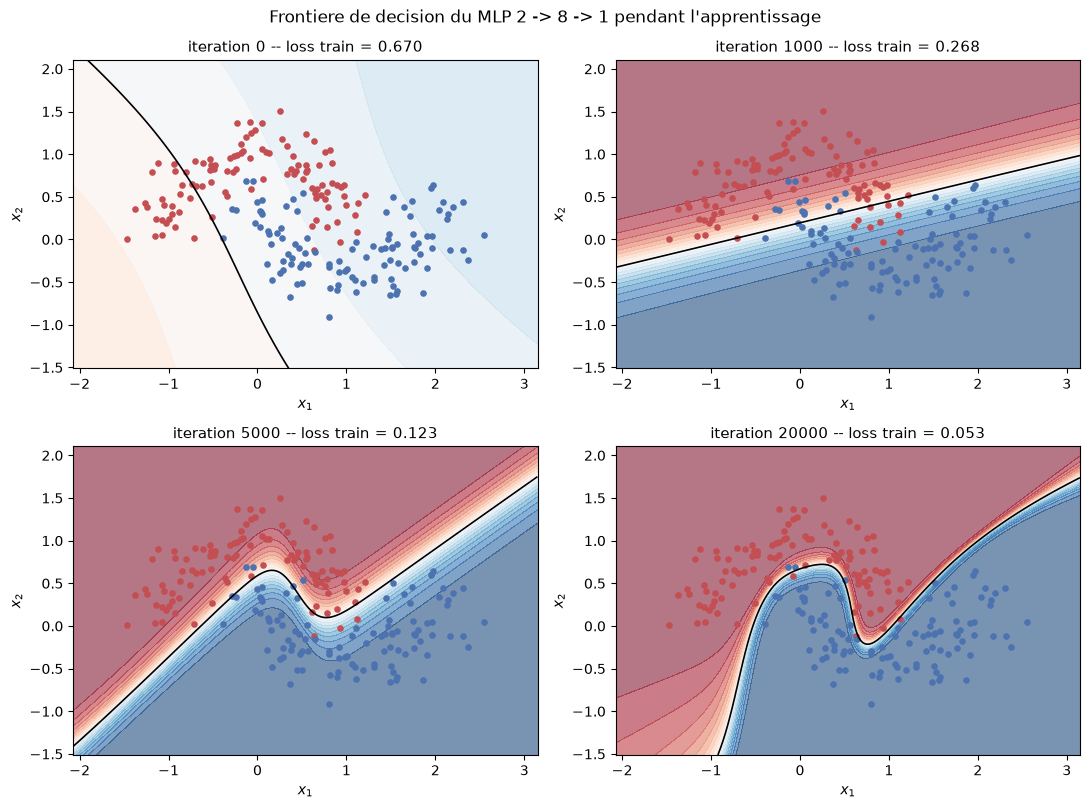

In [7]:
# La frontiere de decision a quatre stades de l'apprentissage
def make_grid(Xd, n=200, pad=0.6):
    xx_, yy_ = np.meshgrid(
        np.linspace(Xd[:, 0].min() - pad, Xd[:, 0].max() + pad, n),
        np.linspace(Xd[:, 1].min() - pad, Xd[:, 1].max() + pad, n),
    )
    return xx_, yy_, np.c_[xx_.ravel(), yy_.ravel()]

def plot_boundary(ax, params, Xd, yd, title, fwd=None):
    """Carte de probabilite du reseau + nuage des exemples (frontiere = niveau 0.5)."""
    if fwd is None:
        fwd = forward
    xx_, yy_, grid_ = make_grid(Xd)
    probs = fwd(params, grid_)[0].reshape(xx_.shape)
    ax.contourf(xx_, yy_, probs, levels=np.linspace(0, 1, 21), cmap="RdBu", alpha=0.55)
    if probs.min() < 0.5 < probs.max():
        ax.contour(xx_, yy_, probs, levels=[0.5], colors="k", linewidths=1.2)
    ax.scatter(Xd[yd == 0, 0], Xd[yd == 0, 1], color="#c44e52", s=14)
    ax.scatter(Xd[yd == 1, 0], Xd[yd == 1, 1], color="#4c72b0", s=14)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))
for ax, (it, p) in zip(axes.ravel(), snaps.items()):
    l = bce_loss(forward(p, X_train)[0], y_train)
    plot_boundary(ax, p, X_train, y_train, f"iteration {it} -- loss train = {l:.3f}")
fig.suptitle("Frontiere de decision du MLP 2 -> 8 -> 1 pendant l'apprentissage")
fig.tight_layout()
plt.show()


### Lecture du résultat

La loss plonge sous le niveau du hasard ($\ln 2$) en quelques centaines d'itérations, puis continue de s'enfoncer : 0.670 → 0.053, et l'accuracy test passe de **0.833** (la meilleure droite, section 1) à **0.944**. La séquence des frontières dit la même histoire : à l'itération 0, le réseau non entraîné découpe le plan de façon quasi arbitraire ; dès 1 000, la frontière est déjà presque une droite (l'essentiel : séparer globalement haut/bas) ; vers 5 000 puis 20 000, elle **se courbe** pour contourner chaque lune — précisément ce qu'aucune droite ne pouvait faire. Les erreurs restantes (5 points sur 90) se logent dans le chevauchement des deux lunes, là où le bruit du générateur a fait déborder des points dans la classe opposée.


## 4. L'effet du learning rate

La boucle ci-dessus fonctionne avec $\eta = 0.5$. Que se passe-t-il quand on le change ? Le learning rate règle la taille du pas : trop petit, chaque itération corrige à peine l'erreur (**stagnation**) ; trop grand, le pas franchit le minimum et rebondit de l'autre côté de la vallée, parfois jusqu'à l'explosion (**divergence**) ; bien réglé, descente rapide et stable. C'est la même leçon qu'au notebook 2.2 — mais désormais vous possédez le code pour la mesurer vous-mêmes.

### Exercice 1 : convergence, stagnation ou divergence ?

Entraînez le même réseau (même `seed=42`, même architecture, 2 000 itérations suffisent) avec $\eta \in \{0.01,\ 0.5,\ 5.0\}$, tracez les trois courbes de loss sur la même figure, et **prédisez avant de lancer** lequel diverge.

Indices :
- `# Étape 1` : `train_mlp(init_params(seed=42), X_train, y_train, lr=..., iters=2000)` — trois fois, un `lr` par courbe.
- `# Étape 2` : tracer les trois `loss_history` sur la même figure ; `plt.yscale("log")` rend la comparaison lisible.
- `# Étape 3` : repérer la divergence : une loss finale supérieure à $\ln 2$ après être montée, ou des valeurs devenues absurdes.
- Lecture attendue : 0.01 stagne (il faudrait ~50× plus d'itérations pour le même effet) ; 0.5 descend bas et vite ; 5.0 est trop grand — le pas saute par-dessus le minimum.


In [8]:
# Exercice 1 : effet du learning rate (eta) sur la descente
losses_eta = {}  # TODO etudiant : boucle sur eta dans [0.01, 0.5, 5.0]
# TODO etudiant : losses_eta[eta] = train_mlp(init_params(seed=42), X_train, y_train, lr=eta, iters=2000)[1]
# TODO etudiant : tracer les trois courbes sur la meme figure (plt.yscale("log") utile)
print("Exercice a completer : 0.01 stagne, 0.5 converge, 5.0 diverge ? Verifiez sur la figure.")


Exercice a completer : 0.01 stagne, 0.5 converge, 5.0 diverge ? Verifiez sur la figure.


## 5. La même chose avec PyTorch : ce qu'autograd fait en silence

Tout ce que nous venons d'écrire — passe avant, cache, chain rule, gradients — PyTorch l'exécute dans `loss.backward()`. Pour le prouver, on construit le même réseau avec `torch.nn.Linear`, la même perte (`BCELoss` sur une sortie sigmoïde), le même optimiseur SGD $\eta = 0.5$, le même nombre d'itérations, et surtout **exactement la même initialisation** : on copie les poids Xavier NumPy dans les tenseurs PyTorch, et on travaille en `float64` pour éliminer les écarts d'arrondi.

Prédiction : loss identique au premier pas, trajectoires quasi identiques, mêmes poids à convergence. Si c'est bien le cas, notre backward à la main calculait exactement ce qu'autograd calcule — et c'est ce qui rend PyTorch fiable : pas de magie, seulement la chain rule industrialisée. (Le GPU serait inutile ici — 33 paramètres, quelques secondes de CPU ; on privilégie l'**exactitude** avant la vitesse. Le GPU redevient utile en 3.2.)


Premier pas : NumPy 0.669933 | PyTorch 0.669933
Dernier pas : NumPy 0.052877 | PyTorch 0.052877
Ecart max sur les 20000 losses : 2.22e-16
Poids a convergence identiques (atol=1e-6) : True


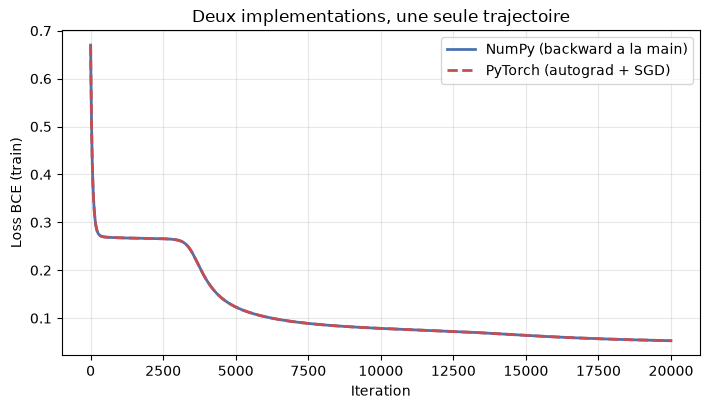

In [9]:
# Le MEME reseau en PyTorch : nn.Linear + BCELoss + SGD, initialisation copiee depuis NumPy
torch.manual_seed(42)

model = torch.nn.Sequential(
    torch.nn.Linear(2, H), torch.nn.Sigmoid(),
    torch.nn.Linear(H, 1), torch.nn.Sigmoid(),
).double()

W1_0, b1_0, W2_0, b2_0 = init_params(seed=42, mode="xavier")  # le meme tirage Xavier que la section 1
with torch.no_grad():
    model[0].weight.copy_(torch.from_numpy(W1_0.T))
    model[0].bias.copy_(torch.from_numpy(b1_0))
    model[2].weight.copy_(torch.from_numpy(W2_0.T))
    model[2].bias.copy_(torch.from_numpy(b2_0))

Xt = torch.from_numpy(X_train)
yt = torch.from_numpy(y_train.reshape(-1, 1)).double()
bce = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

loss_torch = np.empty(20000)
for it in range(20000):
    optimizer.zero_grad()
    loss = bce(model(Xt), yt)
    loss.backward()
    optimizer.step()
    loss_torch[it] = loss.item()

# Contre-partie NumPy : la run de la section 3 -- init_params(seed=42) est deterministe,
# donc les poids copies ci-dessus sont EXACTEMENT ses poids de depart (meme lr, meme budget)
params_np, loss_np = params_train, loss_hist

W1_np, b1_np, W2_np, b2_np = params_np
meme_poids = (
    np.allclose(W1_np, model[0].weight.detach().numpy().T, atol=1e-6)
    and np.allclose(b1_np, model[0].bias.detach().numpy(), atol=1e-6)
    and np.allclose(W2_np, model[2].weight.detach().numpy().T, atol=1e-6)
    and np.allclose(b2_np, model[2].bias.detach().numpy(), atol=1e-6)
)

print(f"Premier pas : NumPy {loss_np[0]:.6f} | PyTorch {loss_torch[0]:.6f}")
print(f"Dernier pas : NumPy {loss_np[-1]:.6f} | PyTorch {loss_torch[-1]:.6f}")
print(f"Ecart max sur les 20000 losses : {np.max(np.abs(loss_np - loss_torch)):.2e}")
print(f"Poids a convergence identiques (atol=1e-6) : {meme_poids}")

plt.figure(figsize=(7.2, 4.2))
plt.plot(loss_np, color="#4c72b0", linewidth=2, label="NumPy (backward a la main)")
plt.plot(loss_torch, color="#c44e52", linewidth=2, linestyle="--", label="PyTorch (autograd + SGD)")
plt.xlabel("Iteration"); plt.ylabel("Loss BCE (train)")
plt.title("Deux implementations, une seule trajectoire")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 6. L'effet de l'initialisation : Xavier contre zéros

Reprenez le réseau ci-dessus et mettez tous les poids **et** biais à zéro. Même architecture, même loss, même $\eta$ — et pendant les premières ~1 700 itérations il ne se passe **strictement rien** : la loss reste collée à $\ln 2 = 0.693$. La raison : la **symétrie**. Si tous les poids de $W_1$ sont nuls, les 8 neurones cachés reçoivent la même entrée (zéro) et produisent tous $A_1 = 0.5$ ; le gradient de $W_1$ est alors identique colonne après colonne, et la mise à jour maintient les colonnes égales. Et comme les classes sont équilibrées (105 / 105 dans le train), $\partial L / \partial b_2 = \mathrm{moyenne}(0.5 - y) = 0$ **en arithmétique exacte**. Chaque neurone est le sosie de son voisin : en arithmétique exacte, le réseau resterait gelé pour toujours.

Mais ce point symétrique n'est pas un minimum : c'est un **col** (point selle). En float64, la somme $\mathrm{moyenne}(0.5 - y)$ laisse un résidu d'arrondi de l'ordre de $10^{-18}$ — une poussière, mais une poussière **non nulle**, qui met $b_2$ en mouvement. Itération après itération, cette graine croît d'environ 2 à 3 % par pas (le col est instable dans la direction qui brise la symétrie) : au bout de ~1 700 itérations elle devient visible et le réseau « s'échappe ». L'échappée ne le sauve pas : parti de nulle part, il atterrit dans un bassin plus mauvais — mesurez-le dans la cellule suivante, loss finale ~0.27 contre ~0.05, accuracy ~86 % contre ~94 %.

L'initialisation de Xavier évite tout ce théâtre : chaque poids est tiré indépendamment autour de 0, avec une variance $1/\mathrm{fan\_in}$ calibrée pour que les activations ne s'éteignent ni ne saturent à travers les couches (Glorot & Bengio, 2010). La symétrie est cassée dès la première itération, et tout le budget d'entraînement sert à apprendre. Même réseau, même loss, même $\eta$ — seul le point de départ change, et avec lui tout le reste.


Init zeros  : figee a ln 2 = 0.6931 pendant 1687 iterations, puis echappee tardive
              loss finale 0.2654, accuracy test 0.856
Init Xavier : loss finale 0.0529, accuracy test 0.944
Norme de W1 apres 20000 iterations : zeros 3.52 | Xavier 17.61


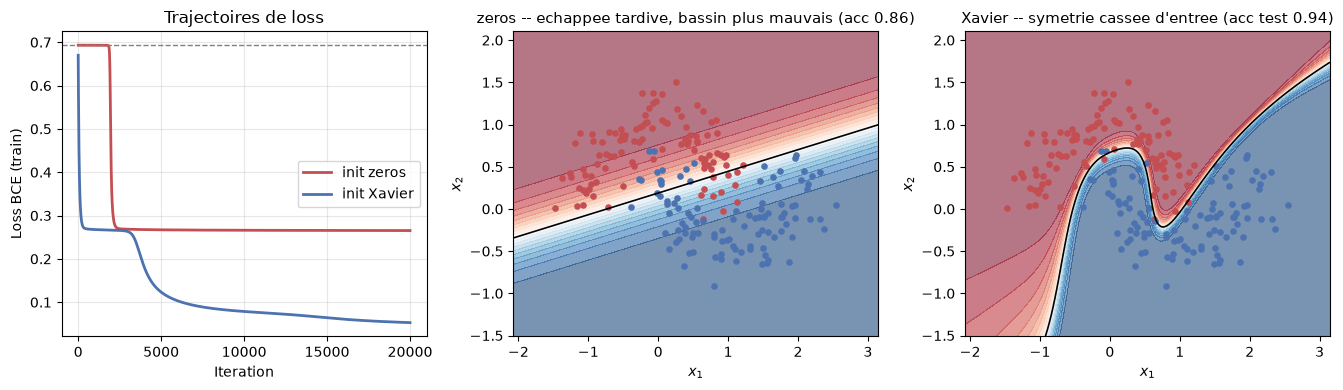

In [10]:
# Xavier vs zeros : meme architecture, meme loss, meme eta -- seul le depart change
params_z, loss_z, _ = train_mlp(init_params(seed=42, mode="zeros"), X_train, y_train, lr=0.5, iters=20000)
params_x, loss_x = params_train, loss_hist  # cote Xavier : la run de la section 3 (config identique)

acc_z = ((forward(params_z, X_test)[0] > 0.5).astype(int).ravel() == y_test).mean()
acc_x = ((forward(params_x, X_test)[0] > 0.5).astype(int).ravel() == y_test).mean()
it_echappee = int(np.argmax(loss_z < np.log(2) - 1e-6))  # premiere iteration ou la loss quitte ln 2

print(f"Init zeros  : figee a ln 2 = {np.log(2):.4f} pendant {it_echappee} iterations, puis echappee tardive")
print(f"              loss finale {loss_z[-1]:.4f}, accuracy test {acc_z:.3f}")
print(f"Init Xavier : loss finale {loss_x[-1]:.4f}, accuracy test {acc_x:.3f}")
print(f"Norme de W1 apres 20000 iterations : zeros {np.linalg.norm(params_z[0]):.2f} | Xavier {np.linalg.norm(params_x[0]):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
axes[0].plot(loss_z, color="#c44e52", linewidth=2, label="init zeros")
axes[0].plot(loss_x, color="#4c72b0", linewidth=2, label="init Xavier")
axes[0].axhline(np.log(2), color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Loss BCE (train)")
axes[0].set_title("Trajectoires de loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
plot_boundary(axes[1], params_z, X_train, y_train, f"zeros -- echappee tardive, bassin plus mauvais (acc {acc_z:.2f})")
plot_boundary(axes[2], params_x, X_train, y_train, f"Xavier -- symetrie cassee d'entree (acc test {acc_x:.2f})")
fig.tight_layout(); plt.show()


## 7. La profondeur : une couche cachée ou deux ?

Notre backward était écrit pour une couche. La beauté de la chain rule : le motif $\delta$ → gradients → $\delta$ se répète à chaque couche, si bien que le code se généralise en une boucle — un réseau devient une simple liste de couches $(W, b)$. Le mini-cas ci-dessous compare $2 \to 8 \to 1$ et $2 \to 8 \to 8 \to 1$ sur `make_circles`, deux cercles concentriques.

### Exercice 2 : prédire, puis faire varier

Avant de lancer la cellule : quelle architecture atteindra la meilleure accuracy test ? Lancez, comparez — puis modifiez les paramètres pour trouver le régime où la profondeur cesse d'être dispensable.

Indices :
- `# Étape 1` : lancer la cellule telle quelle et comparer les deux accuracies affichées.
- `# Étape 2` : réduire la largeur à 4 — remplacer `dims=(2, 8, 1)` par `(2, 4, 1)` et `(2, 4, 4, 1)`. La profondeur compense-t-elle l'étroitesse ?
- `# Étape 3` : augmenter le bruit (`noise=0.25`) — quel réseau résiste mieux au chevauchement des classes ?
- Lecture attendue : contre l'intuition, la profondeur peut **faire perdre** à budget égal — comptez les sigmoïdes que le gradient doit traverser pour revenir à la première couche. Puis doublez les itérations : que devient la comparaison ?


1 couche cachee (2-8-1)      : loss train = 0.0784 | accuracy test = 0.983


2 couches cachees (2-8-8-1)  : loss train = 0.3773 | accuracy test = 0.783


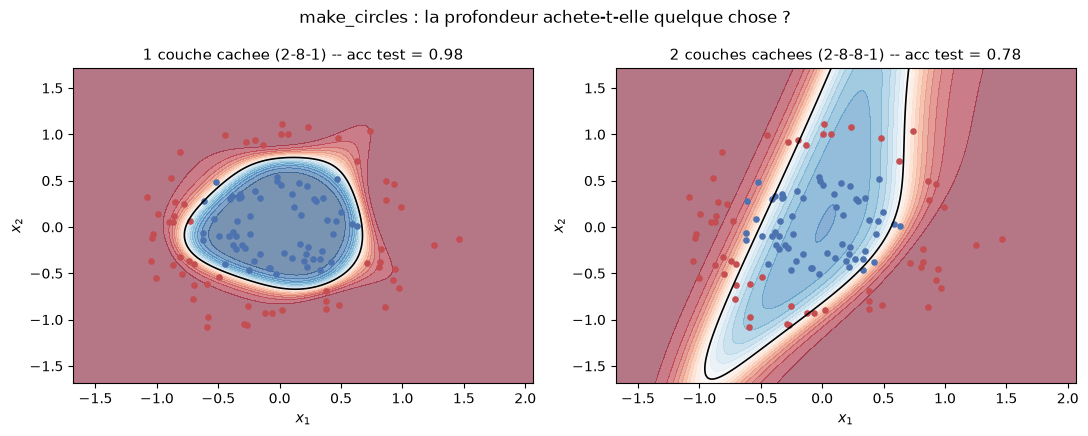

In [11]:
# Mini-cas make_circles : le meme backward, generalise a un nombre quelconque de couches
from sklearn.datasets import make_circles

def forward_gen(Xd, layers):
    """Passe avant generique : A[0] = X, A[k+1] = sigmoid(A[k] @ W_k + b_k), A[-1] = prediction."""
    A = [Xd]
    for W, b in layers:
        A.append(sigmoid(A[-1] @ W + b))
    return A

def backward_gen(layers, y, A):
    """Passe arriere generique : le meme motif delta -> gradients -> delta, en boucle."""
    N = y.shape[0]
    grads = [None] * len(layers)
    delta = (A[-1] - y.reshape(-1, 1)) / N
    for k in range(len(layers) - 1, -1, -1):
        grads[k] = (A[k].T @ delta, delta.sum(axis=0))
        if k > 0:
            delta = (delta @ layers[k][0].T) * A[k] * (1.0 - A[k])
    return grads

def init_layers(dims, seed=42):
    """Xavier couche par couche : W_k ~ N(0, 1/fan_in), biais a zero."""
    rng = np.random.default_rng(seed)
    return [
        (rng.normal(0.0, np.sqrt(1.0 / fan_in), size=(fan_in, fan_out)), np.zeros(fan_out))
        for fan_in, fan_out in zip(dims[:-1], dims[1:])
    ]

def train_gen(layers, Xd, yd, lr=0.5, iters=4000):
    for _ in range(iters):
        A = forward_gen(Xd, layers)
        grads = backward_gen(layers, yd, A)
        layers = [(W - lr * dW, b - lr * db) for (W, b), (dW, db) in zip(layers, grads)]
    return layers

def gen_fwd(layers, Xd):
    return forward_gen(Xd, layers)[-1], None

Xc, yc = make_circles(n_samples=400, noise=0.15, factor=0.4, random_state=42)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=42, stratify=yc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (nom, dims) in zip(axes, [("1 couche cachee (2-8-1)", (2, 8, 1)),
                                   ("2 couches cachees (2-8-8-1)", (2, 8, 8, 1))]):
    Lc = train_gen(init_layers(dims, seed=42), Xc_tr, yc_tr, lr=0.5, iters=4000)
    acc = ((gen_fwd(Lc, Xc_te)[0] > 0.5).astype(int).ravel() == yc_te).mean()
    loss_tr = bce_loss(gen_fwd(Lc, Xc_tr)[0], yc_tr)
    print(f"{nom:28s} : loss train = {loss_tr:.4f} | accuracy test = {acc:.3f}")
    plot_boundary(ax, Lc, Xc_te, yc_te, f"{nom} -- acc test = {acc:.2f}", fwd=gen_fwd)
fig.suptitle("make_circles : la profondeur achete-t-elle quelque chose ?")
fig.tight_layout(); plt.show()


### Lecture du résultat

Surprise mesurée : à budget égal (4 000 itérations), le réseau **profond** fait moins bien que le shallow — accuracy 78 % contre 98 %, loss 0.38 contre 0.08. Ce n'est pas un plafond d'expressivité (deux couches savent représenter tout ce qu'une sait représenter), c'est un coût d'**optimisation** : chaque couche de sigmoïde traversée multiplie le gradient qui remonte par un facteur $\sigma'(z) = a(1-a) \le 0.25$ — le gradient s'amenuise couche après couche (*vanishing gradient*) et les premières couches apprennent au ralenti. Doublez le budget (exercice 2) : le profond rattrape son retard et finit par prendre l'avantage en loss finale. La profondeur achète de l'expressivité mais la paie en vitesse de convergence — ce constat est précisément ce qui a motivé les activations ReLU puis les normalisations, au programme de la suite de la sous-série.


## 8. Capstone : la backward vue comme composition de Jacobiennes

La chain rule tensorielle se réécrit de façon compacte : chaque étape du réseau est une fonction, sa dérivée est une **matrice Jacobienne**, et la rétropropagation est le produit de ces matrices — appliqué **dans l'ordre inverse** et sans jamais les matérialiser en entier (on ne transporte que des *vecteurs* à travers elles : des produits vecteur-Jacobienne). C'est ce qui fait que backpropager coûte à peine plus cher qu'une passe avant, quel que soit le nombre de paramètres.

### Exercice 3 (capstone) : la backward comme composition Jacobienne

Pour le réseau $x \to h = \sigma(W_1^\top x + b_1) \to \hat{y} = \sigma(w_2^\top h + b_2)$ (dimensions 2 → 4 → 1, convention vecteur colonne — la transposée de la convention matricielle en batch des sections précédentes) et **un seul** exemple $(x, y)$ :

1. Écrivez les quatre Jacobiennes : $J_1 = \partial z_1 / \partial x$ (4×2), $J_{\sigma_1} = \partial a_1 / \partial z_1$ (4×4 diagonale), $J_2 = \partial z_2 / \partial a_1$ (1×4), $J_{\sigma_2} = \partial \hat{y} / \partial z_2$ (scalaire).
2. Calculez $\partial L / \partial x$ en multipliant **dans l'ordre inverse**, en ne transportant que des vecteurs : une simple ligne NumPy.
3. Vérifiez chaque composante par différence finie sur $x$ (réutilisez le motif de la section 2) — écart attendu < 1e-7.

Indices :
- `# Étape 1` : $J_1 = W_1^\top$, $J_{\sigma_1} = \mathrm{diag}(a_1 \odot (1 - a_1))$, $J_2 = w_2^\top$.
- `# Étape 2` : en NumPy, inutile de matérialiser la diagonale — multiplier terme à terme par $a_1 \odot (1 - a_1)$ suffit.
- `# Étape 3` : $(L(x + \varepsilon e_i) - L(x - \varepsilon e_i)) / (2 \varepsilon)$ pour $i = 1, 2$, avec $\varepsilon = 10^{-5}$.
- Question bonus : pourquoi backpropager coûte-t-il à peu près une passe avant, quel que soit le nombre de paramètres ? (indice : on ne matérialise jamais les Jacobiennes complètes, seulement des produits vecteur-Jacobienne.)


In [12]:
# Exercice 3 (capstone) : gradient dL/dx comme composition de Jacobienne (reseau 2 -> 4 -> 1, 1 exemple)
x_ex = np.array([[0.8, -0.6]])  # un seul exemple, en ligne comme dans le reste du notebook
y_ex = 1.0
# TODO etudiant : tirer W1 (2x4), b1 (4,), w2 (4,1), b2 (1,) avec np.random.default_rng(0), passe avant
# TODO etudiant : ecrire dL/dx comme produits vecteur-Jacobien, dans l'ORDRE INVERSE (reverse-mode)
dL_dx = None  # TODO etudiant : vecteur (1, 2), a verifier composante par composante par difference finie
print("Exercice a completer : dL/dx via produits vecteur-Jacobien + verification numerique < 1e-7")


Exercice a completer : dL/dx via produits vecteur-Jacobien + verification numerique < 1e-7


## Synthèse et transition

Trois leçons à retenir :

1. **La rétropropagation est la chain rule, rien de plus.** Un $\delta$ remonte de la sortie vers l'entrée ; chaque couche l'utilise pour calculer ses gradients avant de le propager à la couche précédente. Le couple BCE + sigmoïde rend le tout élégant : $\delta_2 = \hat{y} - y$, l'erreur de prédiction elle-même.
2. **La vérification numérique du gradient est la preuve que le code est juste.** Écart analytique/numérique < 1e-7 par différence finie : un filet de sécurité à déployer chaque fois qu'on écrit une dérivée à la main — ici comme dans n'importe quel moteur différentiable.
3. **PyTorch exécute exactement ce qu'on a écrit** — mêmes trajectoires, mêmes poids à convergence. Pas de magie dans `backward()` : c'est ce qui le rend fiable. Et l'initialisation n'est pas un détail : zéros = symétrie gelée à $\ln 2$ ; Xavier = un réseau qui apprend.

Transition : ce réseau a 33 paramètres et tient dans une cellule. Le notebook suivant (`3.2-Entraînement-GPU`) passe aux réseaux plus profonds, aux mini-batchs et au GPU — la mécanique ne change pas, seule l'échelle change.


## References

1. Rumelhart, D., Hinton, G. & Williams, R. (1986). *Learning representations by back-propagating errors*. Nature 323, 533–536. — L'article fondateur : la rétropropagation appliquée aux réseaux multicouches.
2. Glorot, X. & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. AISTATS 2010. — Pourquoi l'initialisation compte : variance $1/\mathrm{fan\_in}$ et rupture de symétrie.
3. Nielsen, M. *Neural Networks and Deep Learning*, chapitre 2 — une dérivation pas à pas de la rétropropagation, avec le point de vue Jacobien.
4. Baydin, A., Pearlmutter, B., Radul, A. & Siskind, J. (2018). *Automatic Differentiation in Machine Learning: a Survey*. JMLR 18. — Forward vs reverse mode : ce qu'autograd fait en silence.
